# Medical imaging project 
In this project, we want to detect pneumonia from chest X-ray images.

We use the available Chest X-ray dataset from Kaggle.

In [ ]:
#Core
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image

#Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

#SQL
import sqlite3

#KaggleHub
import kagglehub
%matplotlib inline



In [3]:
#initial cell with all classes and functions we need

#load images from the Kaggle repo
def load_image_paths(base_path):
    data = []
    
    for split in ["train", "test"]:
        for label in ["NORMAL", "PNEUMONIA"]:
            folder = os.path.join(base_path, "chest_xray", split, label)
            
            for img_name in os.listdir(folder):
                data.append({
                    "path": os.path.join(folder, img_name),
                    "label": label,
                    "split": split
                })
    
    return pd.DataFrame(data)

#create custom dataset class
class XRayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["path"]
        label = self.df.iloc[idx]["label"]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label
    

#function to train our model
def train_model(optimizer, criterion, device, model, train_loader, val_loader, epochs=3):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [4]:
#download the dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset path:", path)

#organize image paths into DataFrame
df = load_image_paths(path)
df.head()

#store in SQL
conn = sqlite3.connect("medical_imaging.db")
df.to_sql("images", conn, if_exists="replace", index=False)

100%|██████████| 2.29G/2.29G [01:41<00:00, 24.4MB/s]

Extracting files...


Dataset path: C:\Users\gemma\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


5840

In [5]:
#clean using SQL
#Remove corrupted / non-image rows (example safeguard)
conn.execute("""
DELETE FROM images
WHERE path IS NULL;
""")

#Create clean table
conn.execute("DROP TABLE IF EXISTS images_clean;")

conn.execute("""
CREATE TABLE images_clean AS
SELECT 
    path,
    CASE 
        WHEN label = 'PNEUMONIA' THEN 1
        ELSE 0
    END AS label,
    split
FROM images;
""")

conn.commit()

#load clean data 
df_clean = pd.read_sql("SELECT * FROM images_clean;", conn)

df_clean.head()

,path,label,split
0,C:\Users\gemma\.cache\kagglehub\datasets\pault...,0,train
1,C:\Users\gemma\.cache\kagglehub\datasets\pault...,0,train
2,C:\Users\gemma\.cache\kagglehub\datasets\pault...,0,train
3,C:\Users\gemma\.cache\kagglehub\datasets\pault...,0,train
4,C:\Users\gemma\.cache\kagglehub\datasets\pault...,0,train


In [6]:
#train/test split
train_df = df_clean[df_clean["split"] == "train"]
test_df = df_clean[df_clean["split"] == "test"]

train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)


In [7]:
#transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#load data
train_dataset = XRayDataset(train_df, transform)
val_dataset = XRayDataset(val_df, transform)
test_dataset = XRayDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [8]:
#build the model, in this case a NN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

#Replace final layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

c:\Users\gemma\anaconda3\envs\ds-ml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\gemma\anaconda3\envs\ds-ml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\gemma/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 20.5MB/s]


In [ ]:
#training set up
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#training loop
CI = os.getenv("CI") == "true"

if CI:
    train_loader = subset(train_loader, size=100)
else:
    train_model(optimizer, criterion, device, model, train_loader, val_loader)
print("Training complete.")

Epoch 1, Loss: 16.0790
Epoch 2, Loss: 7.9922
Epoch 3, Loss: 5.6687
Training complete.


In [15]:
#Evalulation
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())


In [16]:
#print results 
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       234
           1       0.89      0.96      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624

[[189  45]
 [ 16 374]]


# Clinical Interpretation
- Model detects pneumonia with 90% precision
- False negatives are critical → missed diagnosis
- Model could assist radiologists, not replace them

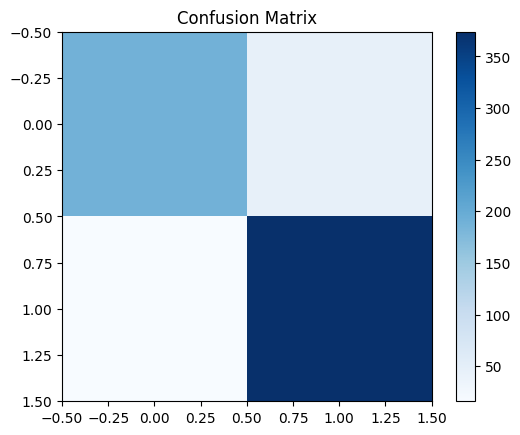

In [13]:
#Visualization
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [14]:
torch.save(model.state_dict(), "models/best_model.pth")